In [17]:
import os
from dotenv import load_dotenv
from langchain_ollama import ChatOllama
from langchain_openai import ChatOpenAI

load_dotenv()

def get_model():
    """Returns a local Llama model or a cloud OpenAI model based on config."""
    # OPTIONS: 'local' or 'cloud'
    provider = os.getenv("LLM_PROVIDER", "local").lower()
    
    if provider == "local":
        # Ensure you have run: ollama pull llama3
        return ChatOllama(
            model="qwen3-vl:8b", 
            base_url="http://localhost:11434",
            temperature=0
        )
    else:
        return ChatOpenAI(
            model="gpt-4o", 
            api_key=os.getenv("OPENAI_API_KEY"),
            temperature=0
        )

In [18]:
!ollama list

NAME                                          ID              SIZE      MODIFIED          
qwen3-vl:8b                                   901cae732162    6.1 GB    About an hour ago    
froehnerel/gorilla-openfunctions:v2-q5_K_M    d2f688262ecd    4.9 GB    4 days ago           
deepseek-r1:8b                                6995872bfe4c    5.2 GB    4 days ago           
tinyllama:latest                              2644915ede35    637 MB    4 months ago         


In [19]:
from langchain_ollama import ChatOllama

# Change model to "qwen2.5" or your pulled version
llm = ChatOllama(
    model="qwen3-vl:8b", 
    base_url="http://localhost:11434",
    temperature=0
)

response = llm.invoke("Explain quantum entanglement in one sentence.")
print(response.content)


Quantum entanglement is a phenomenon where two or more particles become linked such that the state of one instantly influences the state of the other, regardless of the distance separating them, without any communication or violation of relativity.


In [22]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, END

class AgentState(TypedDict):
    file_path: str
    content: str
    summary: str
    critique: str
    attempts: int

def research_node(state: AgentState):
    print(f"--- Researcher (Attempt {state.get('attempts', 0) + 1}) ---")
    
    # 1. Read file if not already in state
    if not state.get("content"):
        with open(state['file_path'], 'r') as f:
            content = f.read()
    else:
        content = state["content"]
        
    # 2. Get summary from swappable model
    model = get_model()
    response = model.invoke(f"Summarize this in one sentence: {content}")
    
    return {
        "content": content, 
        "summary": response.content, 
        "attempts": state.get("attempts", 0) + 1
    }

def critic_node(state: AgentState):
    print("--- Critic ---")
    model = get_model()
    # Logic: Reject if under 15 words
    prompt = f"Critique this summary. If it is too short (under 15 words), say 'REJECT'. Otherwise, say 'PASS'. Summary: {state['summary']}"
    response = model.invoke(prompt)
    return {"critique": response.content}

def router(state: AgentState) -> Literal["summarizer", "end"]:
    """Conditional logic to decide if we loop back."""
    if "REJECT" in state["critique"] and state["attempts"] < 3:
        print("--- REJECTED: Retrying with more detail... ---")
        return "summarizer"
    return "end"

In [24]:
workflow = StateGraph(AgentState)

# Add Nodes
workflow.add_node("summarizer", research_node)
workflow.add_node("critic", critic_node)

# Add Edges
workflow.set_entry_point("summarizer")
workflow.add_edge("summarizer", "critic")

# Add Conditional Edge
workflow.add_conditional_edges(
    "critic",
    router,
    {"summarizer": "summarizer", "end": END}
)

app = workflow.compile()

# RUN IT
with open("input.txt", "w") as f: f.write("The quick brown fox jumps over the lazy dog many times.")

result = app.invoke({"file_path": "input.txt", "attempts": 0})
print("\nFinal Result:", result["summary"])

--- Researcher (Attempt 1) ---
--- Critic ---

Final Result: The sentence repeats the classic English pangram "The quick brown fox jumps over the lazy dog" multiple times.


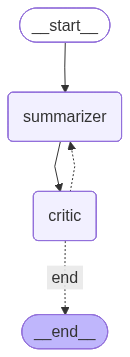

In [25]:
from IPython.display import Image, display
# Assuming 'app' is your compiled graph
display(Image(app.get_graph().draw_mermaid_png()))
